# Heat Equation

In [ ]:
# np.savez_compressed(
#     "wave_results.npz",
#     X=X,
#     T=T,
#     implicit_Dirichlet=np.array(snapshots_implicit_dirichlet),
#     explicit_Dirichlet=np.array(snapshots_explicit_dirichlet),
#     implicit_Neumann=np.array(snapshots_implicit_neumann),
#     explicit_Neumann=np.array(snapshots_explicit_neumann),
#     implicit_Periodic=np.array(snapshots_implicit_periodic),
#     explicit_Periodic=np.array(snapshots_explicit_periodic),
# )

# data = np.load("wave_results.npz")

# X = data["X"]
# T = data["T"]

# # Ejemplo: acceder a un caso específico
# snapshots_implicit_dirichlet = data["implicit_Dirichlet"]
# snapshots_explicit_dirichlet = data["explicit_Dirichlet"]


The two-dimensional diffusion equation is a second-order linear partial differential equation  (PDE) that models conductive heat transfer in different materials and the diffusive movement  of concentration fields, such as the spreading of ink in still water. This equation is a simplified  form of the convection-diffusion equation, assuming that velocity of the media is negligibly  small. The equation is given by:  
$$
\frac{\partial \phi}{\partial t} = D (\frac{\partial^2 \phi}{\partial x^2} + \frac{\partial^2 \phi}{\partial y^2})
$$

where:    
  - $x$ is space component  
  - $t$ is time  
  - $\phi = f(x, y, t)$ is scalar field,  
  - $D$ is the constant diffusion coefficient for the ambient media.  
Solve the equation using the finite difference method in the 2D square domain with the length  of the domain $L$ = 1. The boundary conditions are determined by the last four digits the matriculation number ($9140$). 

The initial condition for $\phi = f(x, y, t)$  are $\phi = f(x, y, 0) = 1$, while the BC depend on the number $M_1 = 9, M_2 = 1, M_3 = 4, M_4 = 0$ with the following definition:

$$
BC = \begin{cases} \phi = 1, & \text{for } M = [0,1,2] \\[6pt]
\phi = 0, & \text{for } M = [3,4,5] \\[6pt]
\phi = x_i^2, & \text{for } M = [6,7,8,9] \end{cases} 
$$

For $M_1$ being west $(x = 0)$, $M_2$ east ($x = x_{max}$), $M_3$ south $(y = 0)$, and $M_4$ north $(y = y_{max})$

Stating that, the boundary conditions for the excercise are:

$$
BC = \begin{cases} 
\phi_{E} = y^2\\[6pt]
\phi_{W} = 1 \\[6pt]
\phi_{S} = 0 \\[6pt]
\phi_{N} = 1 \\[6pt]
\end{cases} 
$$

## Setting up the matrix

Starting from the diffusion equation:

$$
\frac{\partial \phi}{\partial t} = D \left(\frac{\partial^2 \phi}{\partial x^2} + \frac{\partial^2 \phi}{\partial y^2}\right)
$$

it can be written compactly as:

$$
\frac{\partial \phi}{\partial t} = D \nabla^2\phi
$$

Using the **Crank–Nicolson** method for time discretization and **central differences** for the diffusion terms, we obtain:

$$
\frac{\phi_{i,j}^{k+1}-\phi_{i,j}^{k}}{\Delta t}
= D \frac{1}{2}\left[(\nabla^2\phi)*{i,j}^{k+1} + (\nabla^2\phi)*{i,j}^{k}\right]
$$

The Laplacian at each time level is approximated as:

$$
(\nabla^2\phi)*{i,j}^{k} \approx
\frac{\phi*{i+1,j}^{k} - 2\phi_{i,j}^{k} + \phi_{i-1,j}^{k}}{\Delta x^2}
+
\frac{\phi_{i,j+1}^{k} - 2\phi_{i,j}^{k} + \phi_{i,j-1}^{k}}{\Delta y^2}
$$

Substituting this into the Crank–Nicolson scheme gives:

$$
\begin{aligned}
\frac{\phi_{i,j}^{k+1}-\phi_{i,j}^{k}}{\Delta t}
= \frac{D}{2} \Big[ &
\frac{\phi_{i+1,j}^{k+1} - 2\phi_{i,j}^{k+1} + \phi_{i-1,j}^{k+1}}{\Delta x^2}

* \frac{\phi_{i,j+1}^{k+1} - 2\phi_{i,j}^{k+1} + \phi_{i,j-1}^{k+1}}{\Delta y^2} \
  &+
  \frac{\phi_{i+1,j}^{k} - 2\phi_{i,j}^{k} + \phi_{i-1,j}^{k}}{\Delta x^2}
* \frac{\phi_{i,j+1}^{k} - 2\phi_{i,j}^{k} + \phi_{i,j-1}^{k}}{\Delta y^2}
  \Big]
  \end{aligned}
  $$

Defining the coefficients:

$$
\alpha = \frac{D\Delta t}{2\Delta x^2},
\qquad
\beta = \frac{D\Delta t}{2\Delta y^2}
$$

and rearranging terms:

$$
\begin{aligned}
&(1 + 2\alpha + 2\beta),\phi_{i,j}^{k+1}

* \alpha(\phi_{i+1,j}^{k+1} + \phi_{i-1,j}^{k+1})
* \beta(\phi_{i,j+1}^{k+1} + \phi_{i,j-1}^{k+1}) \
  &= (1 - 2\alpha - 2\beta),\phi_{i,j}^{k}

- \alpha(\phi_{i+1,j}^{k} + \phi_{i-1,j}^{k})
- \beta(\phi_{i,j+1}^{k} + \phi_{i,j-1}^{k})
  \end{aligned}
  $$

---

### Identifying the coefficients

We define:

$$
P=(i,j), \quad
E=(i+1,j), \quad
W=(i-1,j), \quad
N=(i,j+1), \quad
S=(i,j-1)
$$

Thus, we can write:

$$
\underbrace{(1+2\alpha+2\beta)}_{A_P}\phi_P^{k+1}
-\underbrace{\alpha}_{A_E}\phi_E^{k+1}
-\underbrace{\alpha}_{A_W}\phi_W^{k+1}
-\underbrace{\beta}_{A_N}\phi_N^{k+1}
-\underbrace{\beta}_{A_S}\phi_S^{k+1}
= Q_P
$$

where:

$$
Q_P = (1 - 2\alpha - 2\beta)\phi_P^{k}

* \alpha(\phi_E^{k} + \phi_W^{k})
* \beta(\phi_N^{k} + \phi_S^{k})
  $$

Finally, the system can be expressed as:

$$
A\boldsymbol{\Phi}^{k+1} = B\boldsymbol{\Phi}^{k}
$$

---

In order to have a decent mapping in the matrix the subindex correspond to the next equation
$$
p = i + j*N_x
$$

In [2]:
# General Setup 
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from dataclasses import dataclass
# from enum import Enum

# class BoundaryCondition(Enum):
#     DIRICHLET = "dirichlet"
#     NEUMANN = "neumann"
#     PERIODIC = "periodic"

# Dataclass added in order to separate parameters from the function, 
# so it will be easier to call when different boundary conditions are used
@dataclass
class SolutionType:
    dx: float
    dt: float
    # boundary_condition: BoundaryCondition

Solve the diffusion equation using Crank-Nicolson time discretization and second order  central difference scheme for diffusion term. Use $D$ = 0.1 and the number of  discretization cells in x and y directions are $N_x$ = $N_y$ = 20. Create a contour plots the  values of $\phi = f(x, y, t)$ for various values of time $\phi = [0,0.5,1,1.5,2]$ within one figure using  subplots. Explain which physical phenomena you observed within these figures -  explain the changes of $\phi = f(x, y, t)$ over time, the influence of initial and boundary  conditions.   

In [ ]:
def animation_from_array_mesh(Nx: int, Ny: int, snapshots: np.ndarray, animation_name: str) -> None:
    import matplotlib.animation as animation
    from matplotlib import rc

    rc("animation", html="jshtml")

    # Creamos malla física simple en [0,1]x[0,1]
    x = np.linspace(0, 1, Nx)
    y = np.linspace(0, 1, Ny)
    X, Y = np.meshgrid(x, y)

    # snapshots: (n_frames, Ny, Nx)
    n_frames = snapshots.shape[0]

    vmin = np.min(snapshots)
    vmax = np.max(snapshots)

    fig, ax = plt.subplots(figsize=(6, 5))

    # Primer frame
    im = ax.imshow(
        snapshots[0],
        origin="lower",
        extent=[x[0], x[-1], y[0], y[-1]],
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Timestep 0")
    ax.grid(False)

    fig.colorbar(im, ax=ax, label="phi")

    def update(frame):
        im.set_data(snapshots[frame])
        ax.set_title(f"Timestep {frame}")
        return [im]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=n_frames,
        interval=120,
        blit=True,
    )

    ani.save(f"{animation_name}.mp4", writer="ffmpeg", fps=10, dpi=100)
    plt.show()


In [93]:
def animation_from_array(Nx: int, Ny: int, dt: float, snapshots: np.ndarray, animation_name: str) -> None:
    import matplotlib.animation as animation
    import matplotlib.pyplot as plt
    from matplotlib import rc
    rc("animation", html="jshtml")

    # Malla física
    x = np.linspace(0, 1, Nx)
    y = np.linspace(0, 1, Ny)
    X, Y = np.meshgrid(x, y)

    n_frames = snapshots.shape[0]

    # Escala de colores fija 0–1
    vmin, vmax = 0.0, 1.0

    fig, ax = plt.subplots(figsize=(7, 6))

    # Primer frame: USAR pcolormesh para gradiente continuo
    cf = ax.pcolormesh(
        X, Y, snapshots[0],
        cmap="viridis",
        vmin=vmin, vmax=vmax,
        shading="gouraud" # Opcional, pero mejora la suavidad
    )

    # Barra de color fija 0–1
    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label("ϕ(x, y, t)", fontsize=12, labelpad=10)
    # ¡Eliminamos set_ticks y set_ticklabels para que sea continuo!

    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("y", fontsize=12)
    ax.set_title("Timestep 0.000 s", fontsize=13)
    ax.set_aspect("equal")

    def update(frame):
        # Limpia SOLO el eje principal (la colorbar se queda)
        ax.clear()

        # USAR pcolormesh para gradiente continuo
        cf = ax.pcolormesh(
            X, Y, snapshots[frame],
            cmap="viridis",
            vmin=vmin, vmax=vmax,
            shading="gouraud" # Opcional, pero mejora la suavidad
        )

        ax.set_xlabel("x", fontsize=12)
        ax.set_ylabel("y", fontsize=12)
        ax.set_title(f"Timestep {frame * dt:.3f} s", fontsize=13)
        ax.set_aspect("equal")

        # No hace falta devolver nada si blit=False
        return []

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=n_frames,
        interval=120,
        blit=False
    )

    ani.save(f"{animation_name}.mp4", writer="ffmpeg", fps=10, dpi=100)
    plt.show()

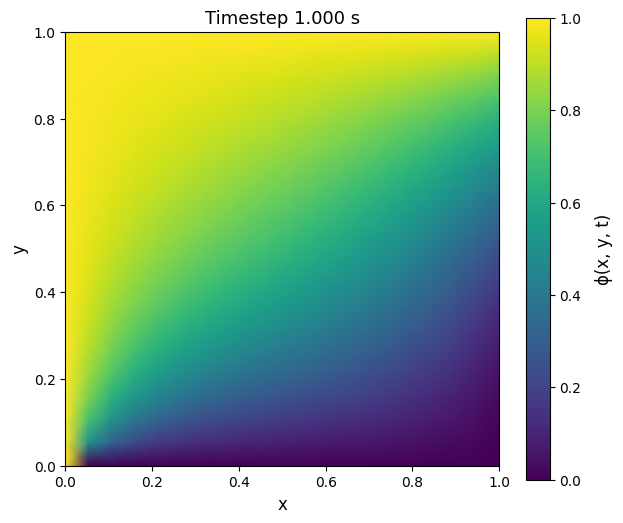

In [97]:
def heat_equation_solver(Nx: int, Ny: int, dt: float):
  # Parameters
  L = 1 # Length of the domain
  T = 1 # Total time

  D = 0.1 # Diffusion Coefficient for the ambient media 

  Nt = int(T/dt) + 1 # Number of time steps

  dx = L / (Nx - 1)
  dy = L / (Ny - 1)

  snapshots = []



  # print(Nx, Ny, Nt)

  x = np.linspace(0, L, Nx)
  y = np.linspace(0, L, Ny)

  # 2D Grid

  X, Y = np.meshgrid(x, y)

  # print("X, Y")
  # print(X, Y)

  # print(dx, dy)

  ALPHA = ((D * dt) / (2 * dx**2))
  BETA = ((D * dt) / (2 * dy**2))

  N = (Nx * Ny)

  # Matrix A | K +1

  A_P = np.ones(N) * (1 + 2 * ALPHA + 2 * BETA)
  A_E = np.ones(N) * -ALPHA
  A_W = np.ones(N) * -ALPHA
  A_N = np.ones(N) * -BETA
  A_S = np.ones(N) * -BETA

  for i in range(Nx-1, N, Nx):
    A_E[i] = 0
    A_W[i] = 0

  offsets = [-Nx, -1, 0, 1, Nx]

  A = diags([A_S, A_W, A_P, A_E, A_N], offsets, shape=(N, N), format="csr") # type: ignore


  # Matrix B | K 

  B_P = np.ones(N) * (1 - 2 * ALPHA - 2 * BETA)
  B_E = np.ones(N) * ALPHA
  B_W = np.ones(N) * ALPHA
  B_N = np.ones(N) * BETA
  B_S = np.ones(N) * BETA

  for i in range(Nx-1, N, Nx):
    B_E[i] = 0
    B_W[i] = 0

  B = diags([B_S, B_W, B_P, B_E, B_N], offsets, shape=(N, N), format="csr") # type: ignore

  PHI_INITIAL = np.ones(N)
  snapshots.append(PHI_INITIAL.copy())

  # Boundary Conditions

  BC_N = np.ones(Nx)
  BC_S = np.zeros(Nx) 
  BC_E = np.zeros(Ny)
  BC_W = np.ones(Ny)

  # For East being y^2
  for j in range(len(y)):
    BC_E[j] = (y[j])**2

  # print("Matrix A: ")
  # print(A.toarray())

  # print("Matrix B: ")
  # print(B.toarray())

  # Boundary Conditions Indexes

  idx_S = np.arange(0, Nx)
  idx_N = np.arange(N - Nx, N)
  idx_W = np.arange(0, N, Nx)
  idx_E = np.arange(Nx - 1, N, Nx)

  # modify to add boundary conditions
  # 
  A = A.tolil()

  for p in np.concatenate([idx_S, idx_N, idx_W, idx_E]):
      A[p, :] = 0
      A[p, p] = 1.0

  A = A.tocsr() 

  PHI_INITIAL[idx_S] = BC_S
  PHI_INITIAL[idx_N] = BC_N
  PHI_INITIAL[idx_W] = BC_W
  PHI_INITIAL[idx_E] = BC_E

  # print("Initial Condition: ")
  # print(PHI_INITIAL.reshape((Ny, Nx)))


  # print("Boundary Conditions: ")
  # print("North: ", BC_N)
  # print("South: ", BC_S)
  # print("East: ", BC_E)
  # print("West: ", BC_W)

  PHI = PHI_INITIAL.copy()

  # print("Phi Initial: ")
  # print(PHI)

  for n in range(1, Nt):
    b = B.dot(PHI)

    # Apply Boundary Conditions to b
    b[idx_S] = BC_S # type: ignore
    b[idx_N] = BC_N # type: ignore
    b[idx_W] = BC_W # type: ignore
    b[idx_E] = BC_E # type: ignore

    PHI = spsolve(A, b)

    # Snapshot
    if n % 1 == 0: # 
      snapshots.append(PHI.copy())

  snapshots = np.array(snapshots)          # (n_frames, N)
  snapshots = snapshots.reshape(-1, Ny, Nx)  # (n_frames, Ny, Nx)
  animation_from_array(Nx, Ny, dt, snapshots, "heat_2d")


heat_equation_solver(20, 20, 0.025)

Use different initial conditions, i.e. $\phi = f(x, y, 0) = 1$, $\phi = f(x, y, t) = 0$ and compare the time  evolution of $\phi$ at the middle point in the domain $\phi = f(0.5, 0.5, t)$. Describe how scalar is  evolved over the time and what is the influence of initial conditions.  

Provide a comparison plot of the time evolution of the scalar field at the point $x = y = 0.5$. Calculate the Von Neumann stability criteria for diffusion equation $G = D\delta t / \delta x^2$. Vary ∆푡 and/or ∆t to achieve G = 0.1, G = 0.3 and G = 5. Provide a  comparison plot of the scalar field at the point x = y = 0.5 over time for different  values of G. Describe this comparison.  

Bonus task: Create an animation of the concentration field evolution over the time  within the whole 2D domain.      